# Q9 - Evaluation 

### Focus a: Metrics and evaluating classifiers 
In this weeks exercises, we worked on evaluation of binary classifiers, where we have a negative and a positive class. 

One important metric is the confusion matrix. It gives us an overview over the true positives, false positives, true negatives and false negatives, when testing our classifier. In this exercise, we have some 20-D data divided between two classes, and a classifier model is trained with 80% of the samples. The confusion matrix shows us what predictions are correct, and if it mostly fails with false negatives or false positives. 

Then we have a bunch of performance metrics. The simplest is accuracy. How many of the predicted values are correct. A good start, but we don't learn anything about what errors our model makes. 
Precision is how many of the predicted positives are actually positives. Relevant if we want to minimize false positives (like spam mail filter). Recall is how many of the actual positives are predicted as positives. This is important if we want to minimize false negatives, like screening for cancer. These two cannot be optimised simultaneously. Tradeoff between precision and recall. Specificity is the rate of true negatives that are correctly predicted. Like recall for negatives. 

The F1-score is a harmonic mean between precision and recall, returning a number between 0 and 1. We want it as close to 1.

These metrics can only be trusted if our dataset is balanced. If we have a majority of positives in our training and testing data, then our model could just be labelling everything as positive and getting good performance metrics. 

The Matthews correlation coefficient uses the entire confusion matrix, and can tell us the quality of the classifier, even if our classes are imbalanced. We want it to be as close to 1. 0 means random classification and -1 means inverse predictions. 

Finally we have the ROC, which illustrates the tradeoff between recall and false positive rate of our model. We want recall to be high, but fpr to be low, but it depends on our classification problem. If it's very important that our recall is 1, then we have to accept some false positives as well. The AUC (area under the curve) is to compare ROCs. Big area is good. Precision recall curve shows tradeoff between the two metrics. These graphs can help select which threshold your binary classifier should use. 

### Focus b: Evaluating regression model
W06 - 02-gaze (assignment 1), right above task 13
Split data into training, validation and test data. For our purpose, only split into training and test. Important to test on unseen data. 
When is regression model good or bad? difference between predicted value and actual value. No negative differences, either absolute or squared. Squared punishes big distances. Different ways to measure distances, 
Look at mean squared error MSE, root mean squared error RMSE and mean absolute error MAE. 
Gaze estimation model, multivariate affine function, seperate model parameters for x and y. 
Model generalization. Does it work well on unseen data. 
Gaze, smaller error for y model than x model. See how error is calculated by vertical difference in prediction dimension. 
Use metrics for model selection, model complexity. W07, 01-polynomial regression. Compare train and test RMSE, sweet spot underfitting/overfitting. 

### Focus c: imbalanced data for classification and regression
imbalance of classes in training data. if class is underrepresented, model might learn to classify everything as majority class to minimize loss. 
Dataset is 90% negative class, 10% positive. We do 5-fold cross-validation and summarise the performance metrics. Recall is very low, and the matthews correlation coefficient also tells us that the model is of low quality. MCC looks past imbalance, could tell us if the model is still good even though our testing data is imbalanced. We want it close to 1. Either remove from majority class, insert duplicates in minority, generate new for minority (generative AI)

For regression, we can have imbalanced data, where some cases are underrepresented. W07, 01-polynomial regression, house prices depending on lot size. Majority of data is smaller lot sizes, underrepresentation of big houses. Handle it like missing data. Imputation of mean, interpolate, or insert using deep learning or generative AI. Also important what data is used for training. If test data is taken from last 10% of samples, underrepresented in training set. Use K-fold cross validation, and choose training data randomly from entire data set. 

# Evaluating Classifiers

**Overview**
This exercise is about evaluation metrics for binary classification. 
The main focus is to evaluate a classification model, irrespective of which model (linear or non-linear) is being used.

Recall that the confusion matrix for binary classification problems has the following structure:

$$
\begin{array}{cc|c|c|}
  & & \text{Predicted Negative} & \text{Predicted Positive} \\
\hline
\text{Actual Negative} & & TN & FP \\
\hline
\text{Actual Positive} & & FN & TP \\
\end{array}
$$
- **TN** - True Negative
- **FN** - False Negative 
- **FP** - False positive
- **TP** - True Positive


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#import">Task 1: Generating Data</a>
            </li>
            <li>
            <a href="#First">Task 2: Training a random Classifier</a>
            </li>
            <li>
            <a href="#accuracy">Task 3: Model accuracy</a>
            </li>
            <li>
            <a href="#classif_report">Task 4: Evaluation</a>
            </li>
            <li>
            <a href="#svc_model">Task 5: Class Imbalance visualization reflection</a>
            </li>
            <li>
            <a href="#metrics">Task 6: ROC and Precision-Recall curves evaluati…</a>
            </li>
        </ul>
    </div>
</article>

## Generating Data

---
**Task 1 (easy): Generating Data👩‍💻**
1. Run the cell below to generate a dataset comprising of 500 samples, 20 features, and 2 classes. This dataset is partitioned using an 80-20 train-test split.


---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_curve, auc, average_precision_score, roc_curve
import classifier_util

import warnings
warnings.filterwarnings("ignore")


X,Y  = datasets.make_classification(n_samples=500, n_features=20, n_classes=2, random_state=1)
print('Dataset Size : ',X.shape,Y.shape)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.80, test_size=0.20, stratify=Y, random_state=1)
print('Train/Test Size : ', X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

Dataset Size :  (500, 20) (500,)
Train/Test Size :  (400, 20) (100, 20) (400,) (100,)


## Performance Metrics
In the following task you will evaluate the model's performance on the test data using different metrics. 

---
**Task 2 (easy): Training a random Classifier👩‍💻**
1. Run the cell below to train a random Classifier.


---

In [2]:
classifier1 = classifier_util.RandomClassifier(random_state=1, C=0.1)
classifier1.fit(X_train, Y_train)


---
**Task 3 (easy): Model accuracy👩‍💻**
Classification accuracy is given by 
$$ \text{accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}$$
 
Run the following cell to make predictions using the `RandomClassifier`
 on the test and training sets. Calculate accuracy by comparing predictions to actual labels: 
1. Calculate model accuracy on the training set.
2. Calculate model accuracy on the test set.
3. Run the cell below to construct and plot the confusion matrix of the model predictions on the training set. 
4. Construct and plot the confusion matrix of the model predictions on the test set. 


---

training accuracy:  0.9525
test accuracy:  0.93


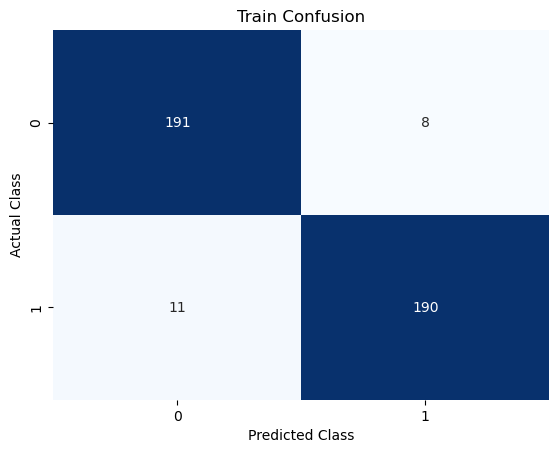

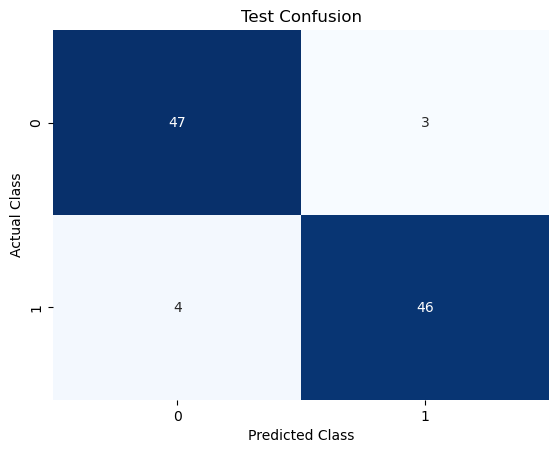

In [10]:
Y_preds = classifier1.predict(X_test)
Y_preds2 = classifier1.predict(X_train)

# Calculate accuracy here ...

train_acc = np.sum(Y_preds2 == Y_train) / len(Y_preds2)
test_acc = np.sum(Y_preds == Y_test) / len(Y_preds)
print("training accuracy: ", train_acc)
print("test accuracy: ", test_acc)


conf_mat_train = confusion_matrix(Y_train, Y_preds2)
sns.heatmap(conf_mat_train, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Train Confusion')
plt.show()

conf_mat_test = confusion_matrix(Y_test, Y_preds)
sns.heatmap(conf_mat_test, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Test Confusion')
plt.show()

**Performance metrics**

**Recall from the lecture**
Performance metrics such as **precision**, **recall**, **F$_1$-score**, **specificity** and **Matthews Correlation Coefficient (MCC)**  provide different views of the performance of the classifier.
- **Precision** - or positive predictive value, represents how many predictions of the positive class actually belong to that class. 

$$
\frac{𝑇𝑃}{𝑇𝑃+𝐹𝑃}
$$


- **Recall** -  also known as sensitivity, true positive rate, or hit rate assesses whether the classifier correctly identifies positive instances out of the total actual postive instances. 

$$
\frac{𝑇𝑃}{𝑇𝑃+𝐹𝑁} 
$$


- **$F_1$-score** - harmonic mean of precision & recall. 

$$
2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision}+\text{Recall}} 
$$


- **Specificity** - also known as the true negative rate, is the percentage of correctly predicted instances of the negative class. 

$$
\frac{TN}{TN+FP} 
$$


- **Matthews Correlation Coefficient (MCC)** - also known as the phi coefficient, is a correlation-based metric that measures the quality of binary classifications, even with imbalanced classes.

$$ 
MCC=\frac{TP \cdot TN-FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$





---
**Task 4 (easy): Performance metrics👩‍💻**
1. Use the confusion matrix of the test data from [Task 3](#accuracy) to find and store the true positive, false positive, true negative and false negative values. 

2. In the cell below calculate the following evaluation metrics for the classification model:
    - Precision
    - Recall
    - F1-score
    - Specificity
    - MCC




---

In [13]:
# write your solution here
TP = 46
FP = 4
TN = 47
FN = 3

precision = TP / (TP + FP)
recall = TP / (TP + FN)
F1_score = 2 * precision * recall / (precision + recall)
specificity = TN / (TN + FP)
MCC = (TP * TN - FP * FN) / np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))

print("precision ", precision)
print("recall ", recall)
print("F1 score ", F1_score)
print("specificity ", specificity)
print("MCC ", MCC)


precision  0.92
recall  0.9387755102040817
F1 score  0.9292929292929293
specificity  0.9215686274509803
MCC  0.8601720516172061



---
**Task 5 (easy): Evaluation💡📽️**
1. Inspect the metrics and reflect on how they individually help in understanding and evaluating the performance of a classification model?
2. How does the MCC help you assess the performance of the models?


---

In [0]:
# Write your reflections here...
#1. The precision tells us that 92% of what the model predicts as positive is actually positive. 
#   Recall tells us that 93% of positive classes are correctly predicted to be positive. 
#       Important if we want to catch all positive cases, like for covid 
#   F1 score is how well precision and recall are balanced. 
#       Important that the data is balanced between the two classes befroe we can use this metric. 
#   Specificity tells us that 92% of negative classes are correctly predicted. 
#   MCC measures quality, even for unbalanced datasets. Between -1 and 1, where 0 is random. 
#       Here we have 0.86, which is good because it's positive and near 1. 
#       The MCC uses all metrics from the confusion matrix, so it takes every metric into account. 

## Imbalanced Classes
The cell below generates a dataset with 1,000 samples across 10 classes. Then an imbalanced dataset is created by combining 9 classes such that all samples in class 0 are marked as positive, while samples in the remaining classes are marked as negative. This results in a 10% positive and 90% negative distribution.


In [14]:
X, Y = datasets.make_classification(n_samples=1000, n_classes=10, n_informative=10)

# Mark the minority class as True
Y = (Y == 0).astype(int)

print('Dataset Size:', X.shape, Y.shape)

# Check the imbalance ratio
imbalance_ratio_actual = np.mean(Y)
print(f'Imbalance Ratio (Positive/Minority Class): {imbalance_ratio_actual:.2f}')

Dataset Size: (1000, 20) (1000,)
Imbalance Ratio (Positive/Minority Class): 0.10



---
**Task 6 (hard): Class Imbalance👩‍💻**
The following task will evaluate `classifier2`
 on the imbalanced dataset.
1. The cell below includes the classifier, variables to store performance metrics, and an incomplete for-loop that performs data splitting for 5-fold cross-validation. Complete the loop so that for each fold:    - Train a `classifier2`
 on the training folds. 
    - Predict labels on the validation folds.
    - Calculate the confusion matrix and the performance metrics on the validation sets (precision, recall, F1-Score, specificity, MCC). Print the average of each metric (use `np.nanmean()`
 as some of these metrics might inlcude NaNs). 




**Info**
In the cell below, the data is randomized before each split. This can lead to slight variations in model performance metrics and graphs, so different results can be expected with each run.


---

In [49]:
classifier2 = classifier_util.RandomClassifier2()

accuracies= []
accuracies, precisions, recalls, f1_scores, specificities, mccs = [], [], [], [], [], []

for train_idx_svc, test_idx_svc in KFold(n_splits=5, shuffle=True).split(X):
    X_train, X_test = X[train_idx_svc], X[test_idx_svc]
    Y_train, Y_test = Y[train_idx_svc], Y[test_idx_svc]

    classifier2.fit(X_train, Y_train)
    Y_pred = classifier2.predict(X_test)
    conf_mat_test = confusion_matrix(Y_test, Y_pred)
    TN = conf_mat_test[0,0]
    FP = conf_mat_test[0,1]
    FN = conf_mat_test[1,0]
    TP = conf_mat_test[1,1]

    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    F1_score = 2 * precision * recall / (precision + recall)
    specificity = TN / (TN + FP)
    MCC = (TP * TN - FP * FN) / np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))

    accuracies.append((TN+TP)/len(Y_test))
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(F1_score)
    specificities.append(specificity)
    mccs.append(MCC)

print("accuracy mean ", np.nanmean(accuracies))
print("precision mean ", np.nanmean(precisions))
print("recall mean ", np.nanmean(recalls))
print("f1 score mean ", np.nanmean(f1_scores))
print("specificity mean ", np.nanmean(specificity))
print("mcc mean ", np.nanmean(mccs))

accuracy mean  0.905
precision mean  0.75
recall mean  0.05719298245614035
f1 score mean  0.17237076648841354
specificity mean  0.994413407821229
mcc mean  0.21224571390965935



---
**Task 7 (hard): Class Imbalance💡📽️**
The following task will evaluate `classifier2`
 on the imbalanced dataset.
1. Why do some of the metrics return NaNs?
2. Is the model able to reliably identify the minority class? 
3. What are the implications for the model's performance and its practical utility?
4. How does the MCC help you assess the performance of the models, especially regarding their ability to handle class imbalance? 


---

In [0]:
# Write your reflections here...
#1. we get NaN when dividing by 0. With our dataset, this could happen as we don't have many positives. 
#2. No, the models ability to correctly predict the positive class is the recall, which is around 1-3% when I rerun it. 
#3. the metrics suggest that the model does not perform well. It cannot correctly classify positives, so it's a pretty bad classifier. 
#4. The mcc usually lies around 0.20, which is pretty low. We would like it be closer to 1. 
#   This means, that even looking past imbalanced classes, the model is simply bad at classifiying the classes. 


---
**Task 8 (hard): Class Imbalance visualization👩‍💻**
1. Run the cell below to plot all the metrics in the same plot.


**Info**
In the cell below, the data is randomized before each split. This can lead to slight variations in model performance metrics and graphs, so different results can be expected with each run.


---

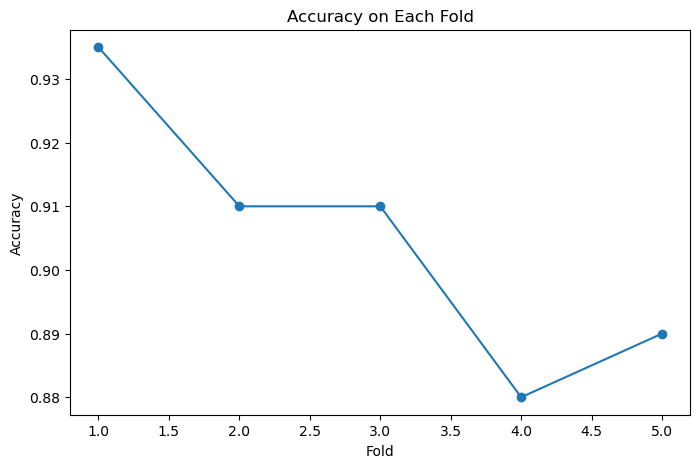

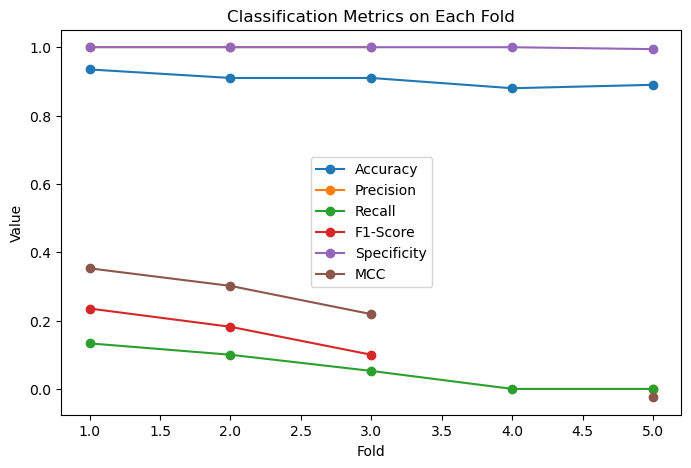

In [51]:
# Step 2
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), accuracies, marker='o')
plt.title('Accuracy on Each Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()

# step 5
# Create a list of metric names for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'MCC']

# Create a list of the values for each metric
metric_values = [accuracies, precisions, recalls, f1_scores, specificities, mccs]

# Plot the metrics on the same plot
plt.figure(figsize=(8, 5))
for i, metric_values_list in enumerate(metric_values):
    plt.plot(range(1, 6), metric_values_list, marker='o', label=metrics[i])

plt.title('Classification Metrics on Each Fold')
plt.xlabel('Fold')
plt.ylabel('Value')
plt.legend()
plt.show()


---
**Task 9 (hard): Class Imbalance visualization reflection💡**
1. Are certain metrics consistently lower? What might this indicate about the model’s handling of the imbalanced data?


---

In [50]:
# write your reflections here
#1. recall, f1 score and MCC are consistently low, if they are not NaN. 
#   This tells us that our model cannot handle the imbalanced dataset, as it's only good at correctly predicting negatives. 

## ROC Curves and Precision-Recall Curves
This task examines the ROC (Receiver Operating Characteristic) curve and the Precision-Recall curve for the classifier trained on the imbalanced dataset. The ROC curve illustrates the trade-off between true positive rate (sensitivity) and false positive rate, while the Precision-Recall curve shows the balance between precision and recall.

---
**Task 10 (medium): ROC and Precision-Recall curves👩‍💻💡**
The cell below divides the dataset (imbalanced) into a training and a test set. It also calculates both the ROC curve and the Precision-Recall curve and extracts relevant metrics such as: `fpr`
 (False Positive Rate), `tpr`
 (True Positive Rate or **recall**), and **precision**.
1. Run the cell below to plot the ROC curve and the Precision-Recall curve.


---

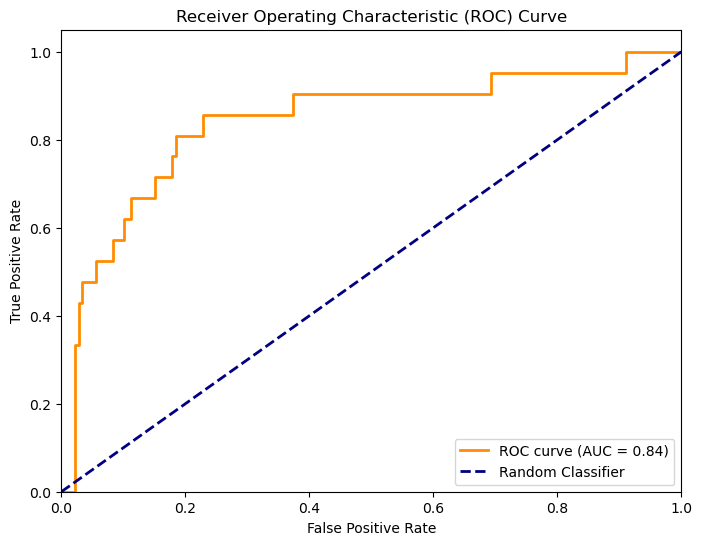

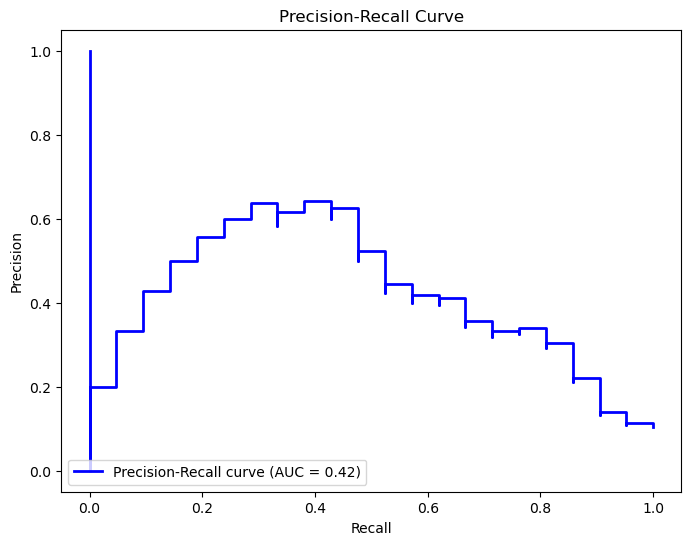

In [52]:
X_train, X_test = X[train_idx_svc], X[test_idx_svc]
Y_train, Y_test = Y[train_idx_svc], Y[test_idx_svc]

# ROC curve
decision_function = classifier2.decision_function(X_test)
fpr, tpr, _ = roc_curve(Y_test, decision_function)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(Y_test, decision_function)
pr_auc = average_precision_score(Y_test, decision_function)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', where='post', lw=2, label='Precision-Recall curve (AUC = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


---
**Task 11 (medium): ROC and Precision-Recall curves evaluation💡📽️**
1. Use the confusion matrix metrics to argue how the plots provide different insights into the classification model's ability to handle class imbalance? 
2. Describe when and why you would prioritize one curve over the other when dealing with imbalanced data.


---

In [0]:
#Write your reflections here...
# see ROC and AUC statquest video 